# 6.2 - Inheritance and Polymorphism (10.4)
***

## Inheritance

- **Inheritance** is a way to form new classes using classes that have already been defined.
- The newly formed classes are called **derived classes**, and the classes that we derive from are called **base classes**.
- Inheritance helps us **reuse code**, reduce duplication, and implement **polymorphic behavior**.

### Syntax of Inheritance in Python

- A class can inherit from another class using the syntax:

```python
class DerivedClass(BaseClass):
    # additional attributes and methods
```
- The derived class inherits all methods and attributes from the base class.
- Here is a base `Player` class:

In [1]:
# Base class
class Player:
  """Class models a player with name, health and description"""
  def __init__(self, name: str, health: int = 100):
    self.name = name
    self.health = health

  def describe(self):
    return f"Player: {self.name}, Health: {self.health}"

- We can make a `Warrior` class that derives from the `Player` class:

In [3]:
class Warrior(Player):
  """Derived Class modeling a warrior player"""
  def __init__(self, name, health, weapon):
    super().__init__(name, health)
    self.weapon = weapon

  def describe(self):
    return f"Warrior: {self.name}, Weapon: {self.weapon}, Health: {self.health}"

- We can now define a more specialized player type called `Warrior` that has a `name` and `health` but now also has a `weapon`.

In [6]:
p = Player("Alina", 100)
w = Warrior("Tomodachi", 400, "spear")

print(p.describe())
print(w.describe())

Player: Alina, Health: 100
Warrior: Tomodachi, Weapon: spear, Health: 400


### Controlling Access to Attributes

- In Python, attributes are **public by default**.
- We can use naming conventions to indicate restricted access:
  - `_attribute`: treated as **protected** (intended for internal use)
  - `__attribute`: treated as **private** (name-mangled to avoid outside access)
- Though Python does not enforce strict access control, these conventions guide usage.

In [7]:
class SecretPlayer:
  def __init__(self, name):
    self.name = name          # public
    # add protected and private attributes below
    self._team = "red" #protected
    self.__score = 100 #private

  def reveal(self):
    return f"{self.name} is on team {self._team} with score {self.__score}"

In [9]:
sp = SecretPlayer("Alinusnus")
print(sp.reveal())

Alinusnus is on team red with score 100


* **Protected** attributes can be accessed, but should be used with caution.

In [10]:
sp._team

'red'

* **private** attributes have their name-mangled to raise an `AttributeError`

In [11]:
sp.__score

AttributeError: 'SecretPlayer' object has no attribute '__score'

* private attributes can still be accessed using the mangled name

In [13]:
sp._SecretPlayer__score

100

### Using `super()`

- The `super()` function gives access to methods and properties of a **base class**.
- It's often used in the `__init__` constructor of the derived class to **initialize the base class**.
- Below we define an `Archer` class that derives from the `Player` class.

In [15]:
class Archer(Player):
  def __init__(self,name,health,arrows):
    super().__init__(name,health)
    self.arrows = arrows

  def describe(self):
    return f"Archer: {self.name}, Arrows: {self.arrows}, Health: {self.health}"

* When an `Archer` object is created, the `super()` function makes a call to the `Player` `__init__` method.

In [16]:
ar = Archer("Ali", 70, 160)

In [17]:
ar.describe()

'Archer: Ali, Arrows: 160, Health: 70'

### Derived Classes as Base Class Objects

- A derived class **is-a** type of base class. This is known as an **is-a relationship**.
- This is different to an attribute of a class, which has an **has-a** relationship.
- You can treat derived class objects as instances of the base class:


In [18]:
players = [Player("Alex"),                # base player class
           Warrior("Bran",100,"sword"),   # derived warrior class
           Archer("Ella",100,20)]         # derived archer class


In [21]:
for p in players:
  print(p.describe())

Player: Alex, Health: 100
Warrior: Bran, Weapon: sword, Health: 100
Archer: Ella, Arrows: 20, Health: 100


- This allows for **uniform treatment** and is useful when working with collections of mixed types.

## Polymorphism

- **Polymorphism** means the same method name behaves differently for different classes.

- We have already seen polymorphic behavior in Python, since Python is polymorphic by default.

- For instance, the following function works regardless of whether we use `int` or `floats`:

In [22]:
def circle_area(radius):
  return 3.14159 * (radius ** 2 )

print(circle_area(5))    # input is int
print(circle_area(3.5))  # input is float

78.53975
38.4844775


- In our example, `describe()` is defined in each subclass, but behaves differently depending on the object.

In [23]:
def introduce(player):
  """Calls decribe method for any player class"""
  print(player.describe())

In [24]:
introduce(p)
introduce(w)

Archer: Ella, Arrows: 20, Health: 100
Warrior: Tomodachi, Weapon: spear, Health: 400


- Polymorphism is implemented by default in Python

### Operator Overloading

- Python allows you to redefine the behavior of operators for user-defined classes.
- This is done by defining **magic methods** like `__add__`, `__eq__`, `__str__`, etc.
- Example:

In [25]:
class ComplexNumber:
  """Represents a complex number a+bi"""

  def __init__(self, real_part, complex_part):
    self.real_part = real_part
    self.complex_part = complex_part

  # overload the addition (+) operator
  def __add__(self, other):
    """add two complex numbers"""
    return ComplexNumber(self.real_part + other.real_part,
                      self.complex_part + other.complex_part)

  # overload the equality (==) comparison operator
  def __eq__(self, other):
    """check if two complex numbers are equal"""
    return (self.real_part == other.real_part
            and self.complex_part == other.complex_part)

  # overload how the class is converted to a string
  def __str__(self):
    return f"{self.real_part} + {self.complex_part}i"

- This allows objects of class `ComplexNumber` to be added with `+` and printed nicely.
- The `__str__` method is a special method for when the class is converted to a string using the `str()` function.
- The `__repr__` is a special method for when the class is printed.

In [27]:
c1 = ComplexNumber(2,3)
c2 = ComplexNumber(5,2)

print(c1)
print(c2)

2 + 3i
5 + 2i


In [29]:
print(c1 + c2)

7 + 5i


In [30]:
c1 == c2

False

In [31]:
c1 == c1

True

## Inheritance Hierarchy

- An inheritance hierarchy describes how classes are related through inheritance.
- `Player` is the **base class**. `Warrior` and `Archer` are **derived classes**.
- This relationship can be visualized as a tree or diagram.

### Inheritance Diagram

- `Player` is the base class
- `Warrior`, `Mage`, and `Archer` are derived classes

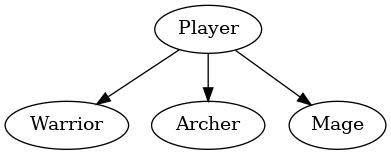

***
# CLASSWORK

1. **Fill-In**:
  * The syntax in Python for `ClassA` inheriting from `ClassB` is ????
  * Suppose `ClassA` inherits from `ClassB`. Then `ClassA` is called the child class and `ClassB` is the parent class.
  * In Python, attributes are ???? by default.
  * To access attributes and methods from the base class, we can use the super() function.
  * When the same method behaves differently for different classes, we call this ????


2. Create a new class `Mage` that inherits from `Player`. Add an attribute `magic` and override the `describe()` method to include the magic.

In [32]:
class Mage(Player):
  def __init__(self, name, health, magic):
    super().__init__(name, health)
    self.magic = magic

  def describe(self):
    return f"Mage: {self.name}, Magic: {self.magic}, Health: {self.health}"

In [33]:
m = Mage("Alili", 500, "fire")

In [34]:
m.describe()

'Mage: Alili, Magic: fire, Health: 500'

3. Create a `User` class with attributes `username` and `password`.
  * Make `username` protected
  * Make `password` private.
  * Make a method called `verify` that returns `True` if the given password is the same as the password attribute.
  * Create a `User` object and try to access the password after construction.

In [ ]:
class User:
  def __init__(self, username, password):
    self._username = username
    self.__password = password

  def verify(self):


## Advanced

4. **Video Game Characters**

For each of the derived classes `Warrior`, `Archer`, and `Mage` defined above, implement an `attack` method with its own logic:

- **Warrior**:
  - Reduces the opponent’s health by **15**

- **Archer**:
  - Reduces opponent’s health by **10**
  - Prints `"Arrow fired!"`

- **Mage**:
  - Reduces opponent’s health by **12**
  - Prints `"Spell cast!"`